<a href="https://colab.research.google.com/github/ashu9439/AI_Lab/blob/main/mnist_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Check for GPU availability:
import torch
print("GPU available:", torch.cuda.is_available())

#If FALSE, activate the GPU by going to Runtime > Change runtime type > Hardware accelerator > GPU.



GPU available: True


In [3]:
!pip install torch torchvision

In [4]:
import torch

# Create a tensor
x = torch.tensor([[1, 2], [3, 4]])
print("Tensor x:\n", x)

# GPU acceleration (if available)
if torch.cuda.is_available():
    device = torch.device("cuda")
    x_gpu = x.to(device)
    print("\nTensor on GPU:\n", x_gpu)


Tensor x:
 tensor([[1, 2],
        [3, 4]])

Tensor on GPU:
 tensor([[1, 2],
        [3, 4]], device='cuda:0')


In [5]:
# Import necessary modules from torchvision and PyTorch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define a series of transformations to be applied to the dataset
# 1. transforms.ToTensor(): Converts PIL images or NumPy arrays to PyTorch tensors.
# 2. transforms.Normalize(): Normalizes the tensor with the specified mean and standard deviation.
#    In this case, the mean is (0.5,) and the standard deviation is (0.5,) for all channels (grayscale images).
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the MNIST training dataset
# 1. root="./data": Specifies the directory where the data will be downloaded.
# 2. train=True: Indicates that this is the training dataset.
# 3. download=True: Downloads the dataset if it is not already available locally.
# 4. transform=transform: Applies the defined transformations to the data.
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Download and load the MNIST testing dataset
# The parameters are similar to the training dataset, but train=False indicates this is the test dataset.
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Create a DataLoader for the training dataset
# 1. train_data: The dataset to load.
# 2. batch_size=64: Specifies the number of samples per batch for training.
# 3. shuffle=True: Randomly shuffles the data at the beginning of each epoch to improve training.
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Create a DataLoader for the testing dataset
# 1. test_data: The dataset to load.
# 2. batch_size=64: Specifies the number of samples per batch for testing.
# 3. shuffle=False: Does not shuffle the data, as shuffling is typically not needed for evaluation.
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Print a confirmation message indicating that the MNIST data has been successfully loaded
print("MNIST data loaded.")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:11<00:00, 895kB/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:06<00:00, 243kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.02MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

MNIST data loaded.


Training Data:


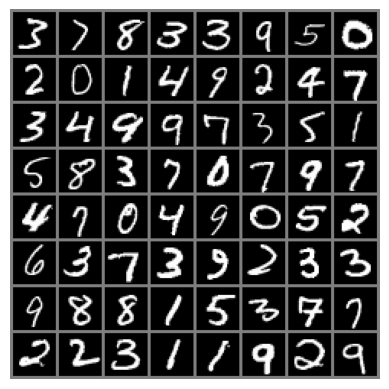

Labels: [3 7 8 3 3 9 5 0 2 0 1 4 9 2 4 7 3 4 9 9 7 3 5 1 5 8 3 7 0 7 9 7 4 7 0 4 9
 0 5 2 6 3 7 3 9 2 3 3 9 8 8 1 5 3 7 7 2 2 3 1 1 9 2 9]
Testing Data:


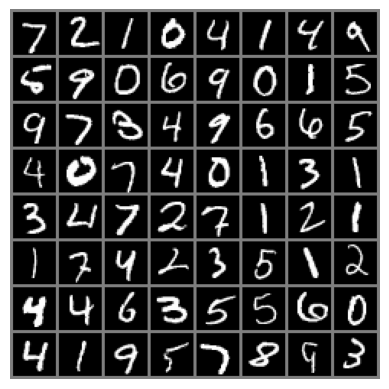

Labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3]


In [7]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Helper function to unnormalize and display images
def imshow(img):
    # Unnormalize the image: reverse the normalization to get the original pixel values
    img = img * 0.5 + 0.5  # Reverse normalization: multiply by std and add mean
    npimg = img.numpy()  # Convert the image to a NumPy array
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Transpose to (H, W, C) format for display
    plt.axis("off")  # Hide axis for better visualization
    plt.show()

# Get some random training images
data_iter = iter(train_loader)  # Create an iterator for the training DataLoader
images, labels = next(data_iter)  # Get a batch of images and labels

# Visualize training images
print("Training Data:")
imshow(torchvision.utils.make_grid(images))  # Display a grid of images
print("Labels:", labels.numpy())  # Print the labels for the batch

# Get some random testing images
data_iter = iter(test_loader)  # Create an iterator for the testing DataLoader
images, labels = next(data_iter)  # Get a batch of images and labels

# Visualize testing images
print("Testing Data:")
imshow(torchvision.utils.make_grid(images))  # Display a grid of images
print("Labels:", labels.numpy())  # Print the labels for the batch


In [8]:
print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [10]:
import torch.nn as nn  # Import PyTorch's neural network module

# Define a simple feedforward neural network by subclassing nn.Module
class SimpleNN(nn.Module):
    def __init__(self):  # Constructor to define the layers
        super(SimpleNN, self).__init__()  # Call the parent class constructor

        # Define the first fully connected layer (input: 28*28, output: 128)
        self.fc1 = nn.Linear(28 * 28, 128)

        # Define the second fully connected layer (input: 128, output: 64)
        self.fc2 = nn.Linear(128, 64)

        # Define the third fully connected layer (input: 64, output: 10)
        # This layer maps to 10 classes for digit classification (0-9)
        self.fc3 = nn.Linear(64, 10)

    # Define the forward pass of the network
    def forward(self, x):
        # Flatten the input tensor from (batch_size, 1, 28, 28) to (batch_size, 28*28)
        x = x.view(-1, 28 * 28)

        # Apply ReLU activation to the output of the first layer
        x = torch.relu(self.fc1(x))

        # Apply ReLU activation to the output of the second layer
        x = torch.relu(self.fc2(x))

        # Pass the output of the second layer to the third layer (no activation here)
        x = self.fc3(x)

        # Return the final output
        return x

# Instantiate the SimpleNN model
model = SimpleNN()

# Print the architecture of the model
print(model)


SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [11]:
# Instantiate the model (assumes SimpleNN is a predefined class for the neural network)
# and move it to the specified device (GPU if available, otherwise CPU).
model = SimpleNN().to(device)

# Loop through the training data loader to get batches of images and labels
for images, labels in train_loader:
    # Move the batch of images and labels to the same device as the model (GPU or CPU).
    # This ensures that computations happen on the same device, avoiding errors.
    images, labels = images.to(device), labels.to(device)

    # Break the loop after processing the first batch.
    # This is typically used for testing or debugging purposes.
    break



In [14]:
## Train

import torch.optim as optim  # Import PyTorch's optimization module

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Ensure the model is on the correct device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Move the model to the selected device

# Training loop
for epoch in range(5):  # 5 epochs
    running_loss = 0  # Track cumulative loss for this epoch

    for images, labels in train_loader:
        # Move data to the same device as the model
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate the loss for this batch
        running_loss += loss.item()

    # Print the average loss for this epoch
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")


Epoch 1, Loss: 0.08705612563285857
Epoch 2, Loss: 0.07593607597017307
Epoch 3, Loss: 0.06626302753907762
Epoch 4, Loss: 0.061260459398397055
Epoch 5, Loss: 0.05576784558259626


In [15]:
# Evaluate


correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [16]:
# Evaluate

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        # Move images and labels to the device (GPU if available)
        images = images.to(device)  # Move images to device
        labels = labels.to(device)  # Move labels to device
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 97.34%
